## 6. Grad-CAM Interpretability

Dans cette partie, nous implémentons Grad-CAM sur notre CNN afin de visualiser les régions de l’image qui influencent les prédictions du modèle sur PathMNIST.

L’objectif est de :
- comprendre où le modèle regarde pour prendre sa décision,
- comparer les zones activées selon différentes classes,
- analyser un exemple de mauvaise prédiction.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST, INFO
import matplotlib.pyplot as plt
import numpy as np

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

info = INFO['pathmnist']
label_dict = info['label']

print("Device utilisé :", device)
print("Classes :", label_dict)

Device utilisé : cpu
Classes : {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


In [17]:
class HistologyCNN(nn.Module):
    def __init__(self):
        super(HistologyCNN, self).__init__()

        # Bloc 1 : 3x28x28 -> 32x14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2)
        )

        # Bloc 2 : 32x14x14 -> 64x7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3)
        )

        # Bloc 3 : 64x7x7 -> 128x3x3
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.4)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(1152, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 9)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

### 1 Chargement des données de test

Nous utilisons les images du jeu de test pour interpréter des prédictions réalisées sur des données non vues pendant l’entraînement.

In [18]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_dataset = PathMNIST(split='test', transform=transform_test, download=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Nombre d'images test :", len(test_dataset))

Nombre d'images test : 7180


In [19]:
model = HistologyCNN().to(device)
model.eval()

print(model)

HistologyCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.4, inpla

### 2 Chargement des poids du CNN entraîné

Nous chargeons ici les poids du CNN entraîné dans la partie 3 afin de produire des heatmaps Grad-CAM pertinentes.

In [20]:
# À exécuter seulement quand tu auras sauvegardé le modèle depuis le fichier 3
model.load_state_dict(torch.load("model_aug_pathmnist.pth", map_location=device))
model.eval()

print("Poids du modèle chargés avec succès")

Poids du modèle chargés avec succès


### 3 Implémentation de Grad-CAM avec hooks PyTorch

Grad-CAM repose sur deux éléments :
- les activations de la dernière couche convolutionnelle,
- les gradients associés à la classe ciblée.

Nous utilisons des hooks PyTorch pour capturer automatiquement ces informations.

In [21]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        # Hook forward : stocke les activations
        self.forward_hook = target_layer.register_forward_hook(self.save_activations)
        # Hook backward : stocke les gradients
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        # Forward
        output = self.model(input_tensor)

        # On annule les gradients précédents
        self.model.zero_grad()

        # Score de la classe ciblée
        score = output[:, class_idx]
        score.backward()

        # Activations et gradients capturés
        activations = self.activations          # shape: [1, C, H, W]
        gradients = self.gradients              # shape: [1, C, H, W]

        # Moyenne des gradients par canal
        weights = gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

        # Combinaison pondérée des activations
        cam = (weights * activations).sum(dim=1)             # [1, H, W]

        # ReLU pour ne garder que les contributions positives
        cam = F.relu(cam)

        # Conversion numpy
        cam = cam.squeeze().detach().cpu().numpy()

        # Normalisation entre 0 et 1
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

### 4 Choix de la couche cible

Nous choisissons la dernière couche convolutionnelle du CNN, car elle contient les représentations visuelles les plus riches tout en conservant une structure spatiale exploitable pour Grad-CAM.

In [22]:
target_layer = model.block3[0]   # dernière couche convolutionnelle
gradcam = GradCAM(model, target_layer)

print("Couche cible choisie :", target_layer)

Couche cible choisie : Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


### 5 Fonctions de visualisation

Nous définissons ici des fonctions pour afficher :
- l’image originale,
- la heatmap Grad-CAM,
- la superposition image + heatmap.

In [24]:
def denormalize_image(img_tensor):
    """
    Annule la normalisation (mean=0.5, std=0.5) pour afficher une image lisible.
    """
    img = img_tensor.clone().detach().cpu()
    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def resize_cam_to_image(cam, target_size=(28, 28)):
    """
    Redimensionne la heatmap à la taille de l'image d'origine.
    """
    cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0).float()
    cam_resized = F.interpolate(cam_tensor, size=target_size, mode='bilinear', align_corners=False)
    return cam_resized.squeeze().numpy()


def show_gradcam_overlay(image_tensor, cam, true_label, pred_label, title="Grad-CAM"):
    """
    Affiche l'image originale, la heatmap seule et l'overlay.
    """
    img = denormalize_image(image_tensor.squeeze(0))
    cam_resized = resize_cam_to_image(cam, target_size=(img.shape[0], img.shape[1]))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title(f"Image originale\nVrai: {true_label}")
    axes[0].axis("off")

    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title("Heatmap Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(img)
    axes[2].imshow(cam_resized, cmap='jet', alpha=0.45)
    axes[2].set_title(f"{title}\nPrédit: {pred_label}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [25]:
def predict_image(model, image_tensor):
    """
    Retourne la classe prédite et les probabilités.
    """
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
    return pred_class, probs.squeeze(0).cpu().numpy()

### 6 Test rapide de Grad-CAM sur une image

Nous vérifions d’abord que l’implémentation fonctionne sur une image quelconque du test set.

Classe vraie : colorectal adenocarcinoma epithelium
Classe prédite : colorectal adenocarcinoma epithelium


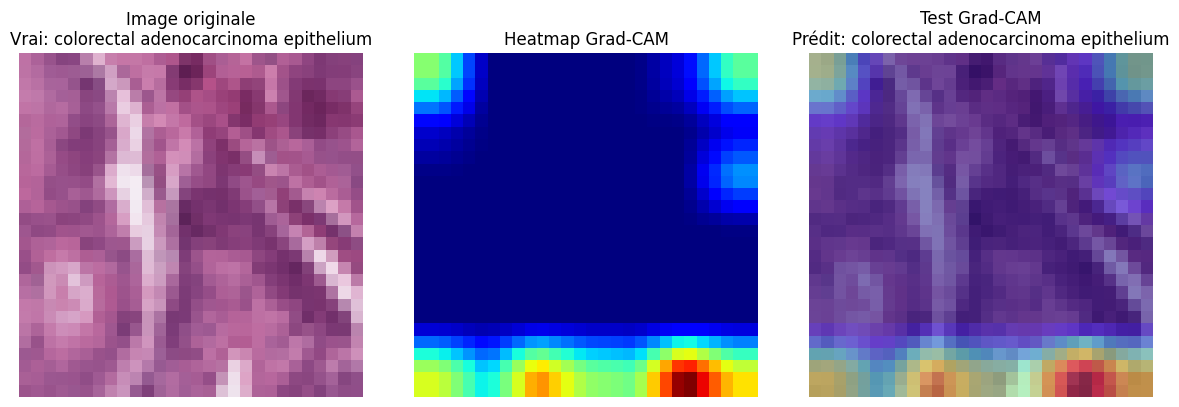

In [26]:
image, label = test_dataset[0]
image = image.unsqueeze(0).to(device)
true_class = label.item()

pred_class, probs = predict_image(model, image)
cam = gradcam.generate(image, pred_class)

true_label_name = label_dict[str(true_class)]
pred_label_name = label_dict[str(pred_class)]

print("Classe vraie :", true_label_name)
print("Classe prédite :", pred_label_name)

show_gradcam_overlay(image, cam, true_label_name, pred_label_name, title="Test Grad-CAM")

In [28]:
def find_misclassified_example(model, dataset, max_search=None):
    """
    Cherche une image mal classée dans le dataset.
    """
    model.eval()
    n = len(dataset) if max_search is None else min(len(dataset), max_search)

    for idx in range(n):
        image, label = dataset[idx]
        true_class = label.item()

        image_batch = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_batch)
            pred_class = torch.argmax(output, dim=1).item()

        if pred_class != true_class:
            return idx, image, true_class, pred_class

    return None

## Q6.1 — Exemple correctement classé : Tumor Epithelium

In [30]:
def find_correct_example_for_class(model, dataset, target_class, max_search=None):
    """
    Cherche une image du dataset appartenant à target_class et correctement prédite.
    """
    model.eval()
    n = len(dataset) if max_search is None else min(len(dataset), max_search)

    for idx in range(n):
        image, label = dataset[idx]
        true_class = label.item()

        if true_class != target_class:
            continue

        image_batch = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_batch)
            pred_class = torch.argmax(output, dim=1).item()

        if pred_class == true_class:
            return idx, image, true_class, pred_class

    return None

Index trouvé : 0


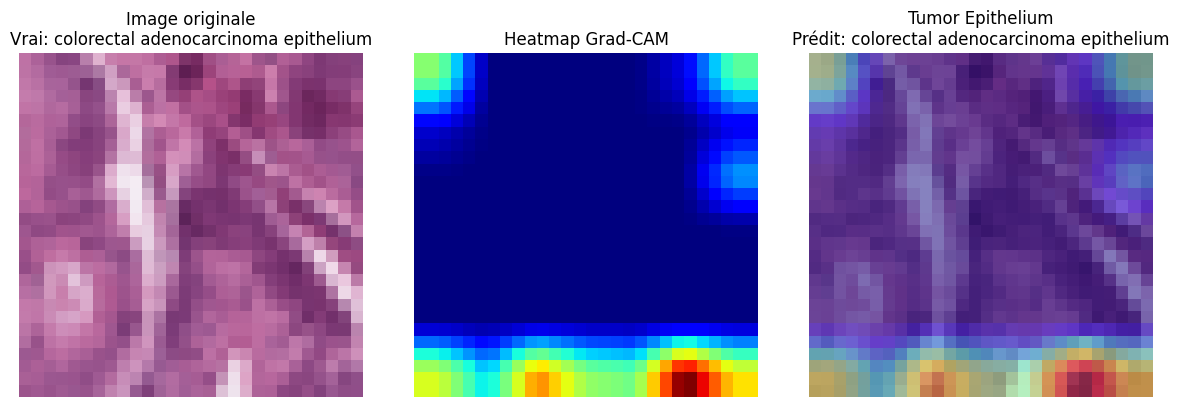

In [31]:
tumor_class = 8  # Colorectal Adenocarcinoma Epithelium / Tumor Epithelium
result_tumor = find_correct_example_for_class(model, test_dataset, tumor_class)

if result_tumor is not None:
    idx, image, true_class, pred_class = result_tumor
    image_batch = image.unsqueeze(0).to(device)

    cam_tumor = gradcam.generate(image_batch, pred_class)

    true_label_name = label_dict[str(true_class)]
    pred_label_name = label_dict[str(pred_class)]

    print("Index trouvé :", idx)
    show_gradcam_overlay(image_batch, cam_tumor, true_label_name, pred_label_name, title="Tumor Epithelium")
else:
    print("Aucun exemple correctement classé trouvé pour Tumor Epithelium.")

## Q6.1 — Exemple correctement classé : Normal Mucosa

Index trouvé : 8


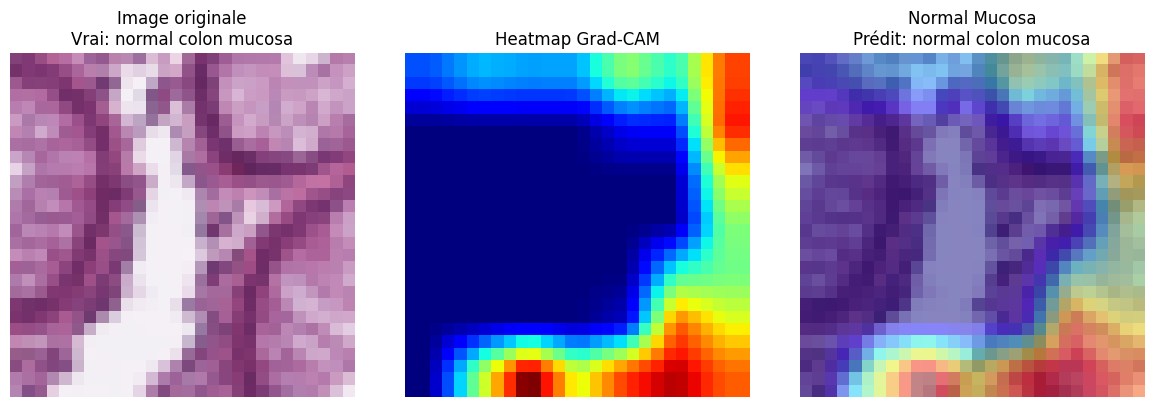

In [37]:
normal_mucosa_class = 6  # Normal Colon Mucosa / Normal Mucosa
result_mucosa = find_correct_example_for_class(model, test_dataset, normal_mucosa_class)

if result_mucosa is not None:
    idx, image, true_class, pred_class = result_mucosa
    image_batch = image.unsqueeze(0).to(device)

    cam_mucosa = gradcam.generate(image_batch, pred_class)

    true_label_name = label_dict[str(true_class)]
    pred_label_name = label_dict[str(pred_class)]

    print("Index trouvé :", idx)
    show_gradcam_overlay(image_batch, cam_mucosa, true_label_name, pred_label_name, title="Normal Mucosa")
else:
    print("Aucun exemple correctement classé trouvé pour Normal Mucosa.")

### Analyse Q6.1

Sur l’image de Tumor Epithelium, la heatmap Grad-CAM met en évidence des zones d’activation plus localisées et plus concentrées. L’attention du modèle est regroupée sur certaines régions spécifiques de l’image, correspondant à des structures tissulaires denses et irrégulières. Ces zones activées apparaissent sous forme de régions compactes, suggérant que le modèle s’appuie sur des motifs locaux marqués pour identifier le caractère tumoral.

En revanche, sur l’image de Normal Mucosa, l’activation est plus diffuse et moins concentrée sur une seule zone. La heatmap met en avant des régions situées principalement sur les bords et dans certaines zones périphériques de l’image, tandis que le centre est relativement peu activé. Cela indique que le modèle s’appuie davantage sur une organisation globale et régulière du tissu, plutôt que sur des anomalies localisées.

Ainsi, les deux heatmaps présentent des comportements distincts : dans le cas tumoral, l’attention est focalisée sur des régions spécifiques et denses, tandis que pour la muqueuse normale, l’activation est plus étalée et structurée, reflétant la régularité du tissu. Cette différence montre que le modèle apprend à distinguer des motifs visuels différents selon la nature du tissu.

## Q6.2 — Analyse d’une image mal classée

In [35]:
def find_misclassified_example(model, dataset, max_search=None):
    """
    Cherche une image mal classée dans le dataset.
    """
    model.eval()
    n = len(dataset) if max_search is None else min(len(dataset), max_search)

    for idx in range(n):
        image, label = dataset[idx]
        true_class = label.item()

        image_batch = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_batch)
            pred_class = torch.argmax(output, dim=1).item()

        if pred_class != true_class:
            return idx, image, true_class, pred_class

    return None

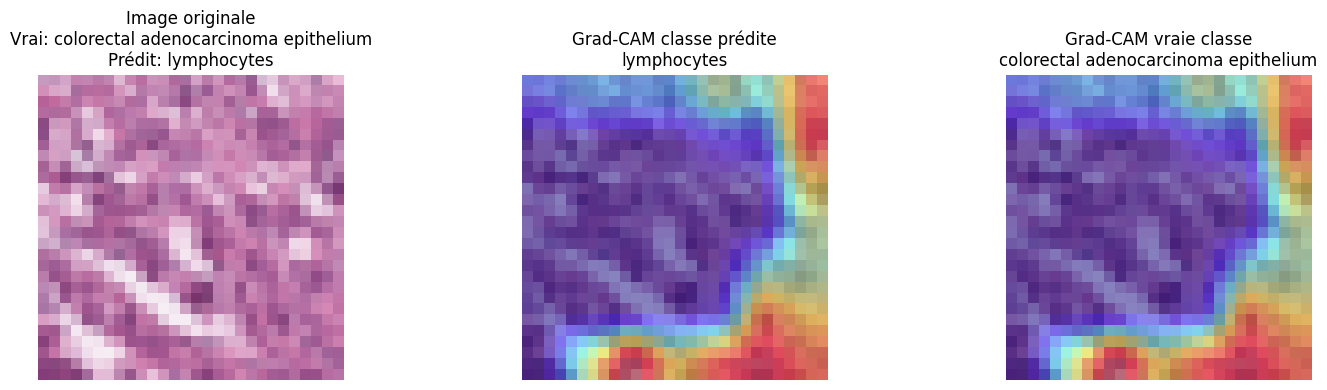

Index trouvé : 3


In [36]:
misclassified = find_misclassified_example(model, test_dataset)

if misclassified is not None:
    idx, image, true_class, pred_class = misclassified
    image_batch = image.unsqueeze(0).to(device)

    # Grad-CAM pour la classe prédite
    cam_pred = gradcam.generate(image_batch, pred_class)

    # Grad-CAM pour la vraie classe
    cam_true = gradcam.generate(image_batch, true_class)

    img = denormalize_image(image_batch.squeeze(0))
    cam_pred_resized = resize_cam_to_image(cam_pred, target_size=(img.shape[0], img.shape[1]))
    cam_true_resized = resize_cam_to_image(cam_true, target_size=(img.shape[0], img.shape[1]))

    true_label_name = label_dict[str(true_class)]
    pred_label_name = label_dict[str(pred_class)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img)
    axes[0].set_title(f"Image originale\nVrai: {true_label_name}\nPrédit: {pred_label_name}")
    axes[0].axis("off")

    axes[1].imshow(img)
    axes[1].imshow(cam_pred_resized, cmap='jet', alpha=0.45)
    axes[1].set_title(f"Grad-CAM classe prédite\n{pred_label_name}")
    axes[1].axis("off")

    axes[2].imshow(img)
    axes[2].imshow(cam_true_resized, cmap='jet', alpha=0.45)
    axes[2].set_title(f"Grad-CAM vraie classe\n{true_label_name}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print("Index trouvé :", idx)
else:
    print("Aucun exemple mal classé trouvé.")

### Analyse Q6.2

Sur cette image mal classée, le modèle prédit la classe *lymphocytes* alors que la vraie classe est *colorectal adenocarcinoma epithelium*. Les deux heatmaps Grad-CAM mettent en évidence des zones globalement similaires, principalement concentrées sur les régions périphériques de l’image, notamment sur les bords droit et inférieur.

Cependant, la heatmap associée à la classe prédite (*lymphocytes*) apparaît légèrement plus diffuse et moins structurée. Le modèle semble se focaliser sur des motifs texturaux généraux présents dans l’image, sans réellement isoler des structures caractéristiques précises.

En revanche, la heatmap associée à la vraie classe (*tumor epithelium*) met en évidence des zones similaires mais avec une intensité légèrement différente, suggérant que certaines régions pertinentes sont bien détectées, mais pas suffisamment exploitées pour orienter correctement la décision.

Cette forte similarité entre les deux heatmaps indique que le modèle se base sur des motifs visuels proches pour les deux classes. Cela suggère que les caractéristiques visuelles de ces deux types de tissus peuvent être similaires localement, ce qui entraîne une confusion du modèle.

Ainsi, l’erreur ne provient pas d’une absence d’information pertinente dans l’image, mais plutôt d’une difficulté du modèle à distinguer des motifs visuels proches entre différentes classes, en particulier dans un contexte de textures histologiques complexes.

In [34]:
gradcam.remove_hooks()
print("Hooks supprimés proprement.")

Hooks supprimés proprement.
